In [2]:
#%pip install xgboost


## Importar librerias

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
import os
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (f1_score, classification_report,
                             confusion_matrix, mean_absolute_error,
                             mean_squared_error)
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, roc_auc_score)
warnings.filterwarnings('ignore')


## Cargar datos

In [4]:
train = pd.read_parquet('m5_train.parquet')
val   = pd.read_parquet('m5_val.parquet')

print(f"Train: {train.shape}")
print(f"Val:   {val.shape}")

Train: (58327370, 27)
Val:   (853720, 27)


## features

In [5]:
features = ['lag_7', 'lag_21', 'lag_28', 'lag_60',
            'ma_7',  'ma_21',  'ma_28',  'ma_60',
            'std_7', 'std_28',
            'wday', 'month', 'snap', 'sell_price']

train['hubo_venta'] = (train['ventas'] > 0).astype('int8')
val['hubo_venta']   = (val['ventas']   > 0).astype('int8')

train_clean = train.dropna(subset=features)
val_clean   = val.dropna(subset=features)

X_train     = train_clean[features]
y_train     = train_clean['ventas']
y_train_bin = train_clean['hubo_venta']

X_val     = val_clean[features]
y_val     = val_clean['ventas']
y_val_bin = val_clean['hubo_venta']

print(f"Train limpio: {train_clean.shape}")
print(f"Val limpio:   {val_clean.shape}")
print(f"% ceros en train: {(y_train == 0).mean()*100:.1f}%")
print(f"% ceros en val:   {(y_val == 0).mean()*100:.1f}%")

Train limpio: (45258166, 28)
Val limpio:   (853720, 28)
% ceros en train: 59.9%
% ceros en val:   54.4%


## Distribución de ventas

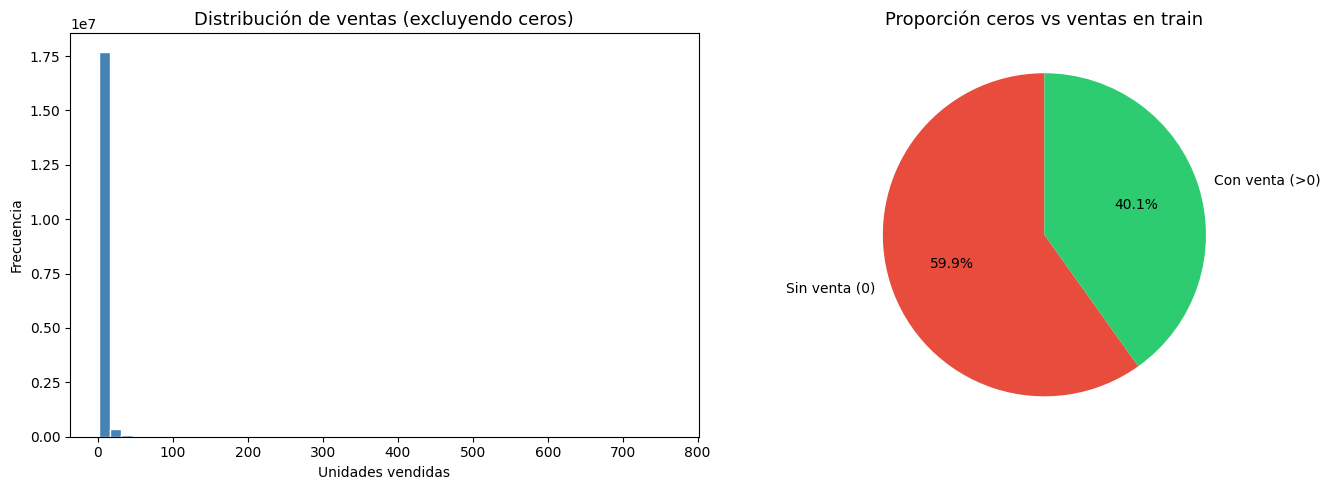

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train[y_train > 0], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de ventas (excluyendo ceros)', fontsize=13)
axes[0].set_xlabel('Unidades vendidas')
axes[0].set_ylabel('Frecuencia')

labels = ['Sin venta (0)', 'Con venta (>0)']
sizes  = [(y_train == 0).sum(), (y_train > 0).sum()]
colors = ['#e74c3c', '#2ecc71']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción ceros vs ventas en train', fontsize=13)

plt.tight_layout()
plt.show()


## CLASIFICADOR ETAPA 1

In [7]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    C            = 0.1,
    penalty      = 'l2',
    solver       = 'saga',
    max_iter     = 2000,
    n_jobs       = -1,
    random_state = 42,
    class_weight = 'balanced'
)
clf.fit(X_train, y_train_bin)

y_pred_bin = clf.predict(X_val)
prob_venta = clf.predict_proba(X_val)[:, 1]

f1        = f1_score(y_val_bin, y_pred_bin)
accuracy  = accuracy_score(y_val_bin, y_pred_bin)
precision = precision_score(y_val_bin, y_pred_bin)
recall    = recall_score(y_val_bin, y_pred_bin)
roc_auc   = roc_auc_score(y_val_bin, prob_venta)

print("=" * 45)
print("   MÉTRICAS CLASIFICADOR (Etapa 1)")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("=" * 45)
print("\nReporte completo:")
print(classification_report(y_val_bin, y_pred_bin,
      target_names=['Sin venta', 'Con venta']))

   MÉTRICAS CLASIFICADOR (Etapa 1)
  Accuracy  : 0.7268
  Precision : 0.7492
  Recall    : 0.6018
  F1 Score  : 0.6675
  ROC-AUC   : 0.7975

Reporte completo:
              precision    recall  f1-score   support

   Sin venta       0.71      0.83      0.77    464725
   Con venta       0.75      0.60      0.67    388995

    accuracy                           0.73    853720
   macro avg       0.73      0.72      0.72    853720
weighted avg       0.73      0.73      0.72    853720



## MATRIZ DE CONFUSION

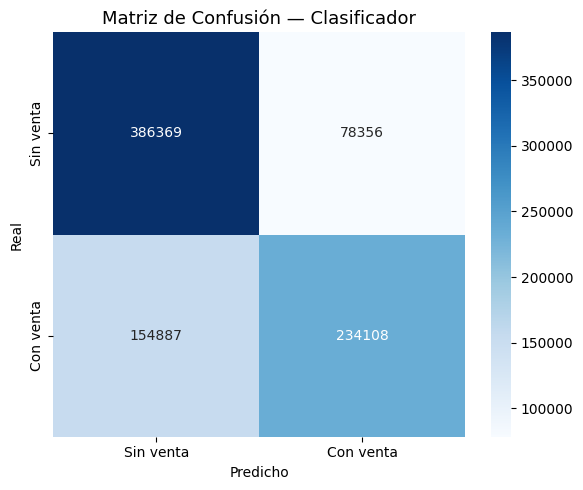

In [8]:

cm = confusion_matrix(y_val_bin, y_pred_bin)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin venta', 'Con venta'],
            yticklabels=['Sin venta', 'Con venta'])
plt.title('Matriz de Confusión — Clasificador', fontsize=13)
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()


## ETAPA 2 REGRESOR + XGBOOST

Filas para regresor: 18,164,935
(40.1% del total)

[0]	validation_0-rmse:6.10998	validation_1-rmse:4.14396
[100]	validation_0-rmse:3.43328	validation_1-rmse:2.35434
[200]	validation_0-rmse:3.28152	validation_1-rmse:2.25739
[300]	validation_0-rmse:3.23183	validation_1-rmse:2.24882
[400]	validation_0-rmse:3.19752	validation_1-rmse:2.24874
[459]	validation_0-rmse:3.18157	validation_1-rmse:2.24862
 XGBoost entrenado


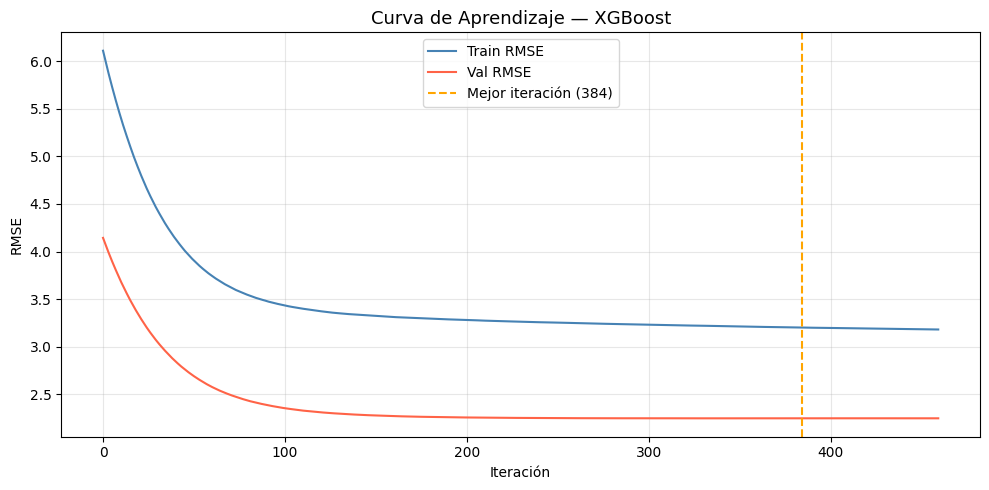

In [37]:
train_venta = train_clean[train_clean['ventas'] > 0]

X_train_reg = train_venta[features]
y_train_reg = train_venta['ventas']

print(f"Filas para regresor: {train_venta.shape[0]:,}")
print(f"({train_venta.shape[0]/train_clean.shape[0]*100:.1f}% del total)\n")

params = {
    'objective':         'reg:squarederror',
    'eval_metric':       'rmse',
    'learning_rate':     0.02,
    'max_depth':         12,
    'min_child_weight':  10,
    'colsample_bytree':  0.6,
    'colsample_bylevel': 0.6,
    'subsample':         0.7,
    'reg_alpha':         0.001,
    'reg_lambda':        0.001,
    'gamma':             0.01,
    'verbosity':         0,
    'n_jobs':            -1,
    'random_state':      42
}

reg = xgb.XGBRegressor(**params, n_estimators=1500, early_stopping_rounds=75)
reg.fit(
    X_train_reg, y_train_reg,
    eval_set=[(X_train_reg, y_train_reg), (X_val, y_val)],
    verbose=100
)
print(" XGBoost entrenado")

resultados_xgb = reg.evals_result()

train_rmse = resultados_xgb['validation_0']['rmse']
val_rmse   = resultados_xgb['validation_1']['rmse']
best_iter  = reg.best_iteration

plt.figure(figsize=(10, 5))
plt.plot(train_rmse, color='steelblue', linewidth=1.5, label='Train RMSE')
plt.plot(val_rmse,   color='tomato',    linewidth=1.5, label='Val RMSE')
plt.axvline(x=best_iter, color='orange', linestyle='--', linewidth=1.5,
            label=f'Mejor iteración ({best_iter})')
plt.title('Curva de Aprendizaje — XGBoost', fontsize=13)
plt.xlabel('Iteración')
plt.ylabel('RMSE')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## PREDICCIÓN FINAL

In [38]:
cantidad_estimada = np.clip(reg.predict(X_val), 0, None)
y_pred_final      = prob_venta * cantidad_estimada

print("Predicciones listas")


Predicciones listas


In [39]:
# Tabla comparativa
df_check = val_clean[['id', 'item_id', 'store_id', 'd', 'ventas']].copy()
df_check['prediccion']   = y_pred_final
df_check['clasificacion'] = y_pred_bin  
df_check['error']        = abs(df_check['ventas'] - df_check['prediccion'])
df_check['acerto_venta'] = (
    (df_check['ventas'] > 0) == (df_check['clasificacion'] == 1)
)

print("=== MUESTRA DE PREDICCIONES ===")
print(df_check[['id', 'd', 'ventas', 'prediccion', 'clasificacion', 
                 'acerto_venta', 'error']].head(28).to_string(index=False))

print(f"\n% días donde acertó si hubo venta o no: "
      f"{df_check['acerto_venta'].mean()*100:.1f}%")
print(f"% días con venta real: "
      f"{(df_check['ventas']>0).mean()*100:.1f}%")
print(f"% días que predijo venta: "
      f"{(df_check['clasificacion']==1).mean()*100:.1f}%")

=== MUESTRA DE PREDICCIONES ===
                         id      d  ventas  prediccion  clasificacion  acerto_venta    error
FOODS_1_001_CA_4_evaluation d_1914       0    0.550577              0          True 0.550577
FOODS_1_001_CA_4_evaluation d_1915       1    0.451043              0         False 0.548957
FOODS_1_001_CA_4_evaluation d_1916       0    0.476701              0          True 0.476701
FOODS_1_001_CA_4_evaluation d_1917       0    0.457050              0          True 0.457050
FOODS_1_001_CA_4_evaluation d_1918       0    0.437705              0          True 0.437705
FOODS_1_001_CA_4_evaluation d_1919       0    0.510043              0          True 0.510043
FOODS_1_001_CA_4_evaluation d_1920       1    0.491805              0         False 0.508195
FOODS_1_001_CA_4_evaluation d_1921       0    0.496939              0          True 0.496939
FOODS_1_001_CA_4_evaluation d_1922       0    0.447848              0          True 0.447848
FOODS_1_001_CA_4_evaluation d_1923    


=== Serie: FOODS_3_090_CA_3_evaluation ===
     d  ventas  prediccion  clasificacion      error
d_1914     133   80.081390              1  52.918610
d_1915     117   77.766266              1  39.233734
d_1916     113   78.037491              1  34.962509
d_1917      99   78.845787              1  20.154213
d_1918     196   81.340385              1 114.659615
d_1919     132  111.593063              1  20.406937
d_1920     114  111.445984              1   2.554016
d_1921     114   92.667282              1  21.332718
d_1922      93   85.959160              1   7.040840
d_1923      77   84.835167              1   7.835167
d_1924      83   87.141365              1   4.141365
d_1925     138   97.870537              1  40.129463
d_1926     173  118.747849              1  54.252151
d_1927     167  111.445984              1  55.554016
d_1928     119   92.667282              1  26.332718
d_1929     119   85.959160              1  33.040840
d_1930     125   78.964920              1  46.035080
d_

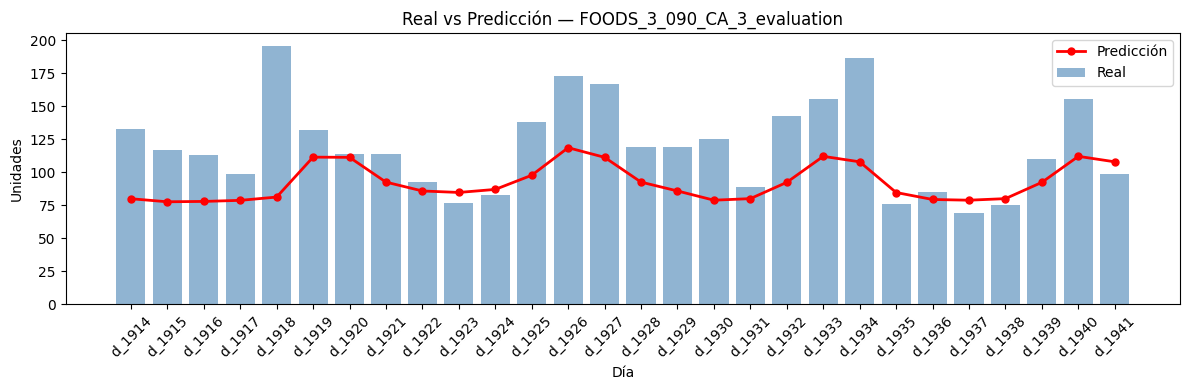

In [41]:
# Ver los 28 días de predicción de un producto en particular
serie = 'FOODS_3_090_CA_3_evaluation'  

df_serie = df_check[df_check['id'] == serie][
    ['d', 'ventas', 'prediccion', 'clasificacion', 'error']
].reset_index(drop=True)

print(f"\n=== Serie: {serie} ===")
print(df_serie.to_string(index=False))

# Graficar
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.bar(df_serie['d'], df_serie['ventas'], 
        alpha=0.6, label='Real', color='steelblue')
plt.plot(df_serie['d'], df_serie['prediccion'], 
         'ro-', label='Predicción', linewidth=2, markersize=5)
plt.title(f'Real vs Predicción — {serie}')
plt.xlabel('Día')
plt.ylabel('Unidades')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## METRICAS

In [42]:
mae  = mean_absolute_error(y_val, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_final))

def calcular_wrmsse_rapido(y_pred, val_clean, train_clean):
    df_val = val_clean[['id', 'ventas']].copy()
    df_val['pred'] = y_pred

    err = df_val.groupby('id').apply(
        lambda x: np.mean((x['ventas'].values - x['pred'].values) ** 2)
    ).reset_index(name='mse')

    escala = train_clean.groupby('id')['ventas'].apply(
        lambda x: np.mean(np.diff(x.values) ** 2)
    ).reset_index(name='escala')

    peso = train_clean.groupby('id')['ventas'].sum().reset_index(name='peso')

    df_m = err.merge(escala, on='id').merge(peso, on='id')
    df_m = df_m[df_m['escala'] > 0]

    return np.sqrt(np.average(df_m['mse'] / df_m['escala'], weights=df_m['peso']))

print("Calculando WRMSSE...")
wrmsse_score = calcular_wrmsse_rapido(y_pred_final, val_clean, train_clean)

print("=" * 45)
print("       RESULTADOS DEL MODELO")
print("=" * 45)
print(f"  F1     (clasificador) : {f1:.4f}")
print(f"  MAE                   : {mae:.4f}")
print(f"  RMSE                  : {rmse:.4f}")
print(f"  WRMSSE                : {wrmsse_score:.4f}")
print("=" * 45)

Calculando WRMSSE...
       RESULTADOS DEL MODELO
  F1     (clasificador) : 0.6675
  MAE                   : 1.0659
  RMSE                  : 2.0064
  WRMSSE                : 0.7573


In [43]:
# Comparar error en train vs val
y_pred_train = np.clip(
    clf.predict_proba(X_train)[:, 1] * reg.predict(X_train), 0, None
)

mae_train  = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

print("=" * 45)
print("   VERIFICACIÓN DE SOBREAJUSTE")
print("=" * 45)
print(f"{'Métrica':<10} {'Train':>10} {'Val':>10} {'Diferencia':>12}")
print("-" * 45)
print(f"{'MAE':<10} {mae_train:>10.4f} {mae:>10.4f} {abs(mae_train-mae):>12.4f}")
print(f"{'RMSE':<10} {rmse_train:>10.4f} {rmse:>10.4f} {abs(rmse_train-rmse):>12.4f}")
print("=" * 45)

if abs(mae_train - mae) / mae < 0.1:
    print(" Sin sobreajuste significativo")
else:
    print("Posible sobreajuste — diferencia mayor al 10%")

   VERIFICACIÓN DE SOBREAJUSTE
Métrica         Train        Val   Diferencia
---------------------------------------------
MAE            1.0978     1.0659       0.0319
RMSE           2.3773     2.0064       0.3709
 Sin sobreajuste significativo


## Graficos de resultados

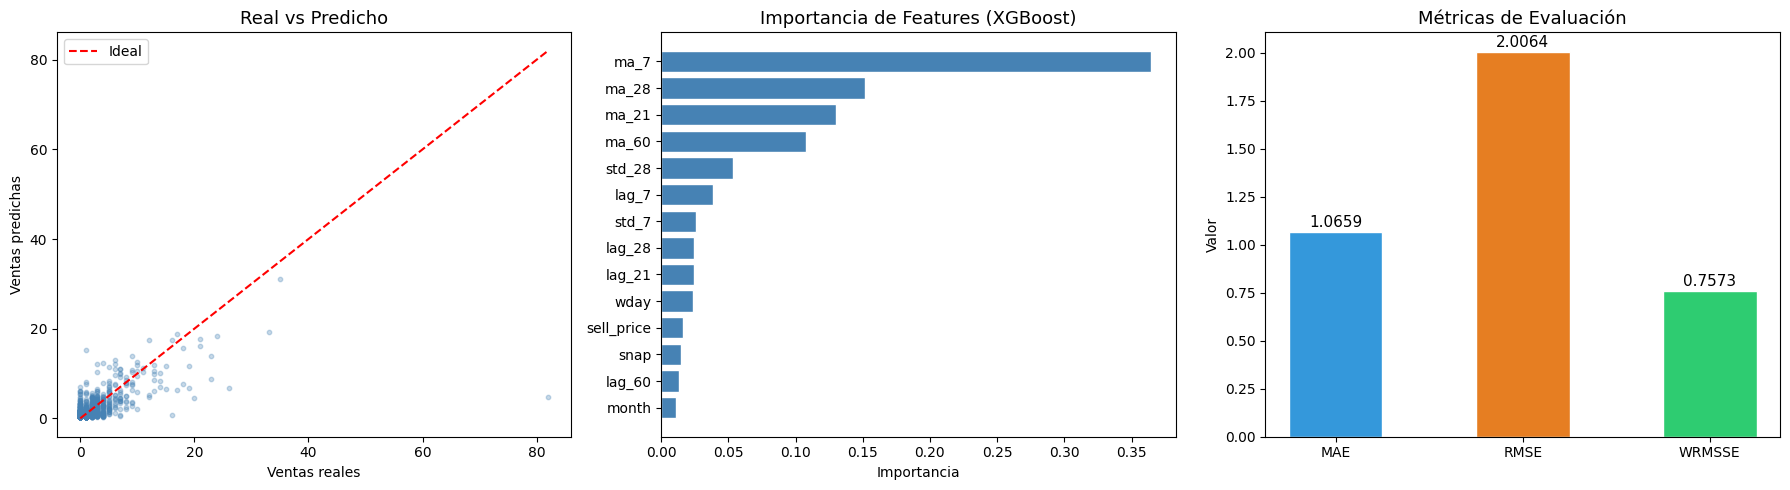

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Real vs Predicho
sample = np.random.choice(len(y_val), size=2000, replace=False)
axes[0].scatter(y_val.values[sample], y_pred_final[sample],
                alpha=0.3, s=10, color='steelblue')
max_val = max(y_val.values[sample].max(), y_pred_final[sample].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Ideal')
axes[0].set_title('Real vs Predicho', fontsize=13)
axes[0].set_xlabel('Ventas reales')
axes[0].set_ylabel('Ventas predichas')
axes[0].legend()

# Importancia de features
importancia = pd.DataFrame({
    'feature':    features,
    'importance': reg.feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(importancia['feature'], importancia['importance'],
             color='steelblue', edgecolor='white')
axes[1].set_title('Importancia de Features (XGBoost)', fontsize=13)
axes[1].set_xlabel('Importancia')

# Métricas resumen
metricas = ['MAE', 'RMSE', 'WRMSSE']
valores  = [mae, rmse, wrmsse_score]
colores  = ['#3498db', '#e67e22', '#2ecc71']
bars = axes[2].bar(metricas, valores, color=colores, edgecolor='white', width=0.5)
for bar, val in zip(bars, valores):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11)
axes[2].set_title('Métricas de Evaluación', fontsize=13)
axes[2].set_ylabel('Valor')

plt.tight_layout()
plt.show()


## Curvas de aprendizaje

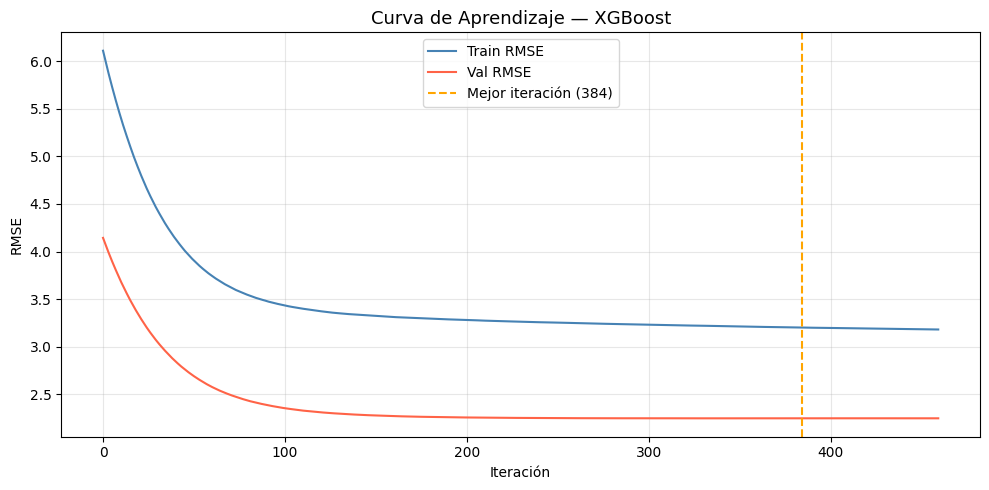

In [45]:
resultados_xgb = reg.evals_result()

train_rmse = resultados_xgb['validation_0']['rmse']
val_rmse   = resultados_xgb['validation_1']['rmse']
best_iter  = reg.best_iteration

plt.figure(figsize=(10, 5))
plt.plot(train_rmse, color='steelblue', linewidth=1.5, label='Train RMSE')
plt.plot(val_rmse,   color='tomato',    linewidth=1.5, label='Val RMSE')
plt.axvline(x=best_iter, color='orange', linestyle='--', linewidth=1.5,
            label=f'Mejor iteración ({best_iter})')
plt.title('Curva de Aprendizaje — XGBoost', fontsize=13)
plt.xlabel('Iteración')
plt.ylabel('RMSE')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Guardar modelo

In [47]:
os.makedirs('modelos', exist_ok=True)

joblib.dump(clf, 'modelos/clasificador2_logistic.pkl')
joblib.dump(reg, 'modelos/regresor_xgboost.pkl')

print("  - modelos/clasificador_logistic.pkl")
print("  - modelos/regresor_xgboost.pkl")



  - modelos/clasificador_logistic.pkl
  - modelos/regresor_xgboost.pkl
